# Amazon Recommender System - Data Modeling

---

## 1. Chuẩn bị thư viện

In [1]:
import sys
import numpy as np
from time import time

sys.path.insert(0, '../src')

from data_processing import (
    load_processed_data,
    encode_interactions_for_modeling,
    standardize_blocks,
)

if 'models' in sys.modules:
    del sys.modules['models']
from models import (
    temporal_split_blocks,
    BaselineModel,
    MatrixFactorizationModel,
    build_exclude_dict,
)

if 'visualization' in sys.modules:
    del sys.modules['visualization']
from visualization import (
    plot_learning_curve,
    plot_baseline_scatter,
)

encode_interactions = encode_interactions_for_modeling
standardize_block = standardize_blocks
split_interactions = temporal_split_blocks

TRAIN_RATIO = 0.8


---
## 2. Tải dữ liệu đã xử lý

In [2]:
print('Loading processed data...')
data, idx_to_user_id, idx_to_product_id = load_processed_data('../data/processed')
print(f"\n✓ Loaded {len(data):,} ratings")
print(f"  Users: {len(idx_to_user_id):,} | Items: {len(idx_to_product_id):,}")
print('  Columns:', data.dtype.names)


Loading processed data...

✓ Loaded 198,502 ratings
  Users: 22,363 | Items: 12,101
  Columns: ('UserId', 'ProductId', 'Rating', 'Timestamp', 'TimestampDT', 'TimeWeight', 'ProductMean')


---
## 3. Trích xuất đặc trưng

In [3]:
encoded_payload, encoded_stats = encode_interactions(data, idx_to_user_id, idx_to_product_id)
ratings_raw = encoded_payload['ratings_raw']
time_weights = encoded_payload['time_weights']
product_means = encoded_payload['product_means']
interactions = encoded_payload['interactions']
n_users = encoded_payload['n_users']
n_items = encoded_payload['n_items']

print('✓ Encoded arrays ready:')
print(f"  Unique users: {n_users:,} | Unique items: {n_items:,}")
print(f"  Rating mean/std: {encoded_stats['rating_mean']:.4f} / {encoded_stats['rating_std']:.4f}")
print('  Time weight range:', f"{encoded_stats['time_weight_min']:.4f} – {encoded_stats['time_weight_max']:.4f}")
print('  Product mean range:', f"{encoded_stats['product_mean_min']:.4f} – {encoded_stats['product_mean_max']:.4f}")


✓ Encoded arrays ready:
  Unique users: 22,363 | Unique items: 12,101
  Rating mean/std: 4.1904 / 1.1666
  Time weight range: 0.2000 – 1.0000
  Product mean range: 1.0000 – 5.0000


### Tóm tắt feature

- Dùng `TimeWeight` (min–max timestamp về [0.2, 1.0]) làm trọng số cho MF để tránh phụ thuộc các yếu tố phức tạp.
- Thêm `ProductMean` (average rating sau k-core) để Popularity baseline sử dụng.


---
## 4. Chia train/test theo thời gian
 
Sắp xếp toàn bộ tương tác theo timestamp (toàn cục) rồi lấy 80% sớm nhất cho train, 20% mới nhất cho test. Đây là temporal split - chia dữ liệu dựa trên thời gian.

In [4]:

train_block, test_block, split_stats = split_interactions(encoded_payload, TRAIN_RATIO, verbose=True)

train_users = train_block['users']
train_items = train_block['items']
train_timestamps = train_block['timestamps']
train_weights = train_block['weights']

test_users = test_block['users']
test_items = test_block['items']
test_timestamps = test_block['timestamps']
test_weights = test_block['weights']

train_ratings_raw = train_block['ratings_raw']
test_ratings_raw = test_block['ratings_raw']
train_product_means = train_block['product_means']
test_product_means = test_block['product_means']



Split stats (temporal 80/20):
  Train interactions: 158,802
  Test interactions:  39,700
  Users train/test: 20,833 / 10,219
  Items train/test: 11,776 / 8,834
  Time weight range (train): 0.2000 – 0.9750
  Time weight range (test):  0.9750 – 1.0000


### 4.1 Thống kê sau khi chia

In [5]:

n_users = len(idx_to_user_id)
n_items = len(idx_to_product_id)
print('Dataset summary after split:')
print('=' * 60)
print(f"Total ratings: {len(data):,}")
print(f"Train/Test: {train_ratings_raw.size:,} / {test_ratings_raw.size:,}")
print(f"Sparsity: {100 * (1 - len(data)/(n_users * n_items)):.4f}%")
print(f"Train rating range (raw): {train_ratings_raw.min():.1f} – {train_ratings_raw.max():.1f}")
print(f"Test rating range  (raw): {test_ratings_raw.min():.1f} – {test_ratings_raw.max():.1f}")
print('=' * 60)


Dataset summary after split:
Total ratings: 198,502
Train/Test: 158,802 / 39,700
Sparsity: 99.9266%
Train rating range (raw): 1.0 – 5.0
Test rating range  (raw): 1.0 – 5.0


### 4.2 Chuẩn hóa rating

Rating được chuẩn hoá (z-score) trên tập train để MF học trên thang chuẩn, sau đó áp dụng mean/std này cho test và tính lại product mean chuẩn hoá.


In [6]:
standardized = standardize_block(train_block, test_block, n_items)
train_ratings_std = standardized['train_ratings_std']
test_ratings_std = standardized['test_ratings_std']
train_product_means_std = standardized['train_product_means_std']
test_product_means_std = standardized['test_product_means_std']
train_matrix = standardized['train_matrix']
test_matrix = standardized['test_matrix']
rating_mean_train = standardized['rating_mean']
rating_std_train = standardized['rating_std']

print(f"Rating mean/std (train, raw): {rating_mean_train:.4f} / {rating_std_train:.4f}")
print(f"Rating mean/std (train, z-score): {train_ratings_std.mean():.4f} / {train_ratings_std.std():.4f}")
print('Product mean (train, z-score) range:', f"{train_product_means_std.min():.4f} – {train_product_means_std.max():.4f}")


Rating mean/std (train, raw): 4.1785 / 1.1699
Rating mean/std (train, z-score): 0.0000 / 1.0000
Product mean (train, z-score) range: -2.7169 – 0.7022


---
## 5. Tạo danh sách loại trừ

In [7]:

exclude_dict = build_exclude_dict(train_users, train_items)
print(f"Exclude dictionary built for {len(exclude_dict):,} active users")


Exclude dictionary built for 20,833 active users


---
## 6. Baseline Popularity

In [8]:
pop_train_matrix = np.column_stack([
    train_users,
    train_items,
    train_ratings_std,
    train_timestamps,
    train_product_means_std
])

pop_test_matrix = np.column_stack([
    test_users,
    test_items,
    test_ratings_std,
    test_timestamps,
    test_product_means_std
])

print('\n' + '=' * 70)
print('MODEL 1: POPULARITY BASELINE')
print('=' * 70)

pop_model = BaselineModel()
start = time()
pop_model.fit(pop_train_matrix)
pop_time = time() - start
pop_rmse = pop_model.evaluate(pop_test_matrix)
print(f"Training time: {pop_time:.2f}s | RMSE: {pop_rmse:.4f}")



MODEL 1: POPULARITY BASELINE
Training time: 0.04s | RMSE: 1.0049


---
## 7. Mô hình Matrix Factorization

In [9]:
np.random.seed(2025)

mf_model = MatrixFactorizationModel(
    n_users=n_users,
    n_products=n_items,
    n_factors=50,
    learning_rate=0.005,
    regularization=0.1,
    n_epochs=100,
    early_stopping=True,
    patience=10,
    use_standardized_targets=False
)

print('\n' + '=' * 70)
print('MODEL 2: MATRIX FACTORIZATION (SGD, time-weighted, rating z-score)')
print('=' * 70)
start = time()
mf_model.fit(train_matrix, test_matrix, verbose=True)
train_time = time() - start
mf_rmse = mf_model.evaluate(test_matrix)
print(f"Training time: {train_time:.2f}s | RMSE: {mf_rmse:.4f}")



MODEL 2: MATRIX FACTORIZATION (SGD, time-weighted, rating z-score)

────────────────────────────────────────────────────────────────────────
» Huấn luyện Matrix Factorization | k=50, lr=0.005, reg=0.1
────────────────────────────────────────────────────────────────────────
  epoch |    train |     test |   Δt(s)
---------------------------------------
      1/100 |   0.9747 |   0.9864 |    3.23
      2/100 |   0.9480 |   0.9799 |    3.15
      3/100 |   0.9261 |   0.9752 |    3.05
      4/100 |   0.9073 |   0.9715 |    3.10
      5/100 |   0.8906 |   0.9686 |    3.05
      6/100 |   0.8755 |   0.9662 |    3.14
      7/100 |   0.8618 |   0.9642 |    3.31
      8/100 |   0.8492 |   0.9626 |    3.37
      9/100 |   0.8375 |   0.9612 |    3.07
     10/100 |   0.8266 |   0.9600 |    3.06
     11/100 |   0.8164 |   0.9591 |    3.21
     12/100 |   0.8068 |   0.9582 |    3.66
     13/100 |   0.7977 |   0.9575 |    3.58
     14/100 |   0.7891 |   0.9569 |    3.49
     15/100 |   0.7809 |   0.

---
## 8. So sánh & đánh giá


RMSE COMPARISON
Popularity baseline : 1.0049
MF (weighted SVD): 0.9547
Improvement vs baseline: 5.00%

Best model: MF weighted SVD


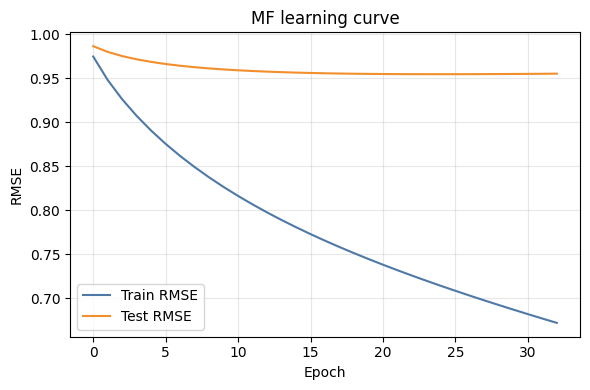

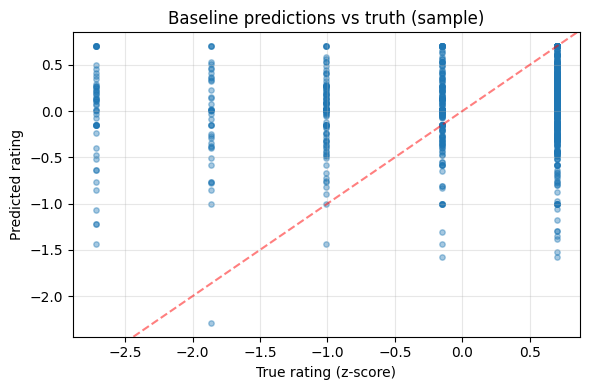

In [10]:
print('\n' + '=' * 70)
print('RMSE COMPARISON')
print('=' * 70)
print(f"Popularity baseline : {pop_rmse:.4f}")
print(f"MF (weighted SVD): {mf_rmse:.4f}")
improvement = 100 * (pop_rmse - mf_rmse) / pop_rmse
print(f"Improvement vs baseline: {improvement:.2f}%")
best = 'MF weighted SVD' if mf_rmse < pop_rmse else 'Popularity'
print(f"\nBest model: {best}")
print('=' * 70)

plot_learning_curve(mf_model.train_rmse_history, mf_model.test_rmse_history)
plot_baseline_scatter(pop_test_matrix, pop_model)


---
## 9. Nhận xét
- **Popularity baseline (RMSE 1.0049)**: mô hình trung bình product mean (chuẩn hóa) nên chạy cực nhanh (<0.2s) và bao phủ user/item chưa từng xuất hiện (cold-start). Dù vậy scatter so với rating thật cho thấy sai số lớn ở item hiếm hoặc user có sở thích khác biệt ⇒ thích hợp nhất làm fallback.
- **Matrix Factorization (RMSE 0.9547)**: cải thiện ~5% so với baseline, early stopping dừng tại epoch 32/100 (~60s). Learning curve train/test chạy song song nhờ regularization + trọng số thời gian ⇒ mô hình ổn định, ít overfit.
- **Bao phủ dữ liệu**: khoảng 70% user test và 82% item đã xuất hiện trong train nên MF tận dụng embedding để cá nhân hóa; phần còn lại giao cho baseline giúp hệ thống luôn trả kết quả.
